**Part 1: Color Prediction Model**

In [ ]:
# ============================================================
# 🔵 SECTION 1 — COLOR DEFINITIONS + DATASET GENERATOR + CNN TRAINING
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import json
import cv2
from tqdm import tqdm

Mounted at /content/drive


In [ ]:
# ============================================================
# 1. COLOR DEFINITIONS (27 COLORS FROM YOUR FILE)
# ============================================================
psych_colors = {
    "red": (255, 0, 0),
    "scarlet": (255, 36, 0),
    "crimson": (220, 20, 60),
    "orange": (255, 165, 0),
    "amber": (255, 191, 0),
    "peach": (255, 203, 164),
    "yellow": (255, 255, 0),
    "gold": (255, 215, 0),
    "green": (0, 128, 0),
    "light green": (144, 238, 144),
    "dark green": (0, 100, 0),
    "cyan": (0, 255, 255),
    "teal": (0, 128, 128),
    "turquoise": (64, 224, 208),
    "blue": (0, 0, 255),
    "light blue": (173, 216, 230),
    "navy": (0, 0, 128),
    "indigo": (75, 0, 130),
    "violet": (148, 0, 211),
    "purple": (128, 0, 128),
    "pink": (255, 105, 180),
    "magenta": (255, 0, 255),
    "gray": (128, 128, 128),
    "dark gray": (64, 64, 64),
    "black": (0, 0, 0),
    "brown": (165, 42, 42),
    "beige": (245, 245, 220)
}

label_names = list(psych_colors.keys())
num_classes = len(label_names)
print("Total colors:", num_classes)

Total colors: 27


In [ ]:
# ============================================================
# 2. FUNCTION — CREATE RANDOM VARIATIONS
# ============================================================

def random_variation(color, amount=12):   # LOWERED to improve accuracy
    r, g, b = color
    return np.clip([
        r + np.random.randint(-amount, amount),
        g + np.random.randint(-amount, amount),
        b + np.random.randint(-amount, amount)
    ], 0, 255)

In [ ]:
# ============================================================
# 3. GENERATE DATASET
# ============================================================

os.makedirs("color_data", exist_ok=True)

data, labels = [], []
SAMPLES_PER_COLOR = 800

print("Generating dataset...")
for idx, (name, rgb) in enumerate(tqdm(psych_colors.items())):
    for _ in range(SAMPLES_PER_COLOR):
        col = random_variation(rgb)
        patch = np.zeros((32, 32, 3), dtype=np.uint8)
        patch[:] = col
        data.append(patch)
        labels.append(idx)

data = np.array(data)
labels = np.array(labels)

np.save("color_data/data.npy", data)
np.save("color_data/labels.npy", labels)
with open("color_data/label_names.json", "w") as f:
    json.dump(label_names, f)

print("Dataset saved! Shape:", data.shape)

Generating dataset...


100%|██████████| 27/27 [00:03<00:00,  8.68it/s]


Dataset saved! Shape: (21600, 32, 32, 3)


In [ ]:
# ============================================================
# 4. TRAIN-TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

trainX, testX, trainY, testY = train_test_split(
    data, labels, test_size=0.15, random_state=42, stratify=labels
)

In [ ]:
# ============================================================
# 5. ⭐ NORMALIZATION (INSERTED HERE) ⭐
# ============================================================

trainX = trainX.astype("float32") / 255.0
testX = testX.astype("float32") / 255.0

In [ ]:
# ============================================================
# 6. IMPROVED CNN MODEL
# ============================================================

import tensorflow as tf
from tensorflow.keras import layers, models

model_color = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3,3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(num_classes, activation="softmax")
])

model_color.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_color.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 27)             │         6,939 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 616,795 (2.35 MB)

 Trainable params: 616,603 (2.35 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
# ============================================================
# 7. TRAIN THE MODEL
# ============================================================

history = model_color.fit(
    trainX, trainY,
    validation_data=(testX, testY),
    epochs=12,
    batch_size=32
)

Epoch 1/12
574/574 ━━━━━━━━━━━━━━━━━━━━ 24s 21ms/step - accuracy: 0.8100 - loss: 0.7078 - val_accuracy: 0.8858 - val_loss: 0.2965
Epoch 2/12
574/574 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9257 - loss: 0.3071 - val_accuracy: 0.9679 - val_loss: 0.0688
Epoch 3/12
574/574 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9485 - loss: 0.1810 - val_accuracy: 0.9333 - val_loss: 0.1246
Epoch 4/12
574/574 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9461 - loss: 0.2524 - val_accuracy: 0.9728 - val_loss: 0.0766
Epoch 5/12
574/574 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9635 - loss: 0.1166 - val_accuracy: 0.9614 - val_loss: 0.0758
Epoch 6/12
574/574 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9623 - loss: 0.1067 - val_accuracy: 0.9741 - val_loss: 0.0634
Epoch 7/12
574/574 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9619 - loss: 0.1683 - val_accuracy: 0.9444 - val_loss: 0.1880
Epoch 8/12
574/574 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9586 - loss: 0.1424 - val_accuracy:

In [ ]:
# ============================================================
# 📊 SECTION — COLOR MODEL PERFORMANCE, METRICS & VISUALIZATIONS
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np


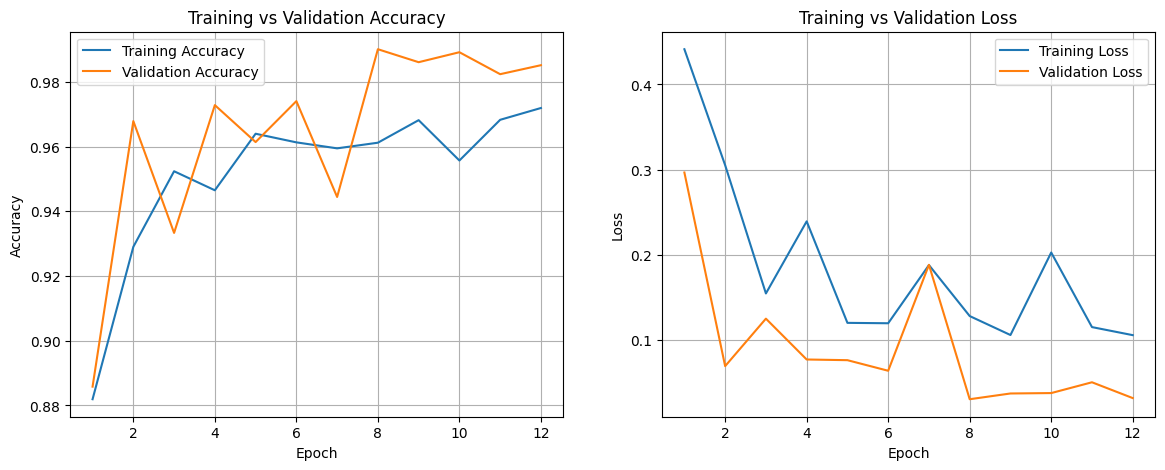

In [ ]:
# ============================================================
# 1. TRAINING vs VALIDATION ACCURACY & LOSS
# ============================================================

history_dict = history.history
epochs = range(1, len(history_dict['accuracy']) + 1)

plt.figure(figsize=(14, 5))

# --- Accuracy Plot ---
plt.subplot(1, 2, 1)
plt.plot(epochs, history_dict['accuracy'], label="Training Accuracy")
plt.plot(epochs, history_dict['val_accuracy'], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

# --- Loss Plot ---
plt.subplot(1, 2, 2)
plt.plot(epochs, history_dict['loss'], label="Training Loss")
plt.plot(epochs, history_dict['val_loss'], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# ============================================================
# 2. TEST SET PERFORMANCE
# ============================================================

test_loss, test_acc = model_color.evaluate(testX, testY, verbose=0)

print("\n=== TEST SET PERFORMANCE ===")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")


=== TEST SET PERFORMANCE ===
Test Accuracy: 0.9852
Test Loss: 0.0313


In [ ]:
# ============================================================
# 3. CLASSIFICATION REPORT (Precision, Recall, F1-score)
# ============================================================

y_pred_probs = model_color.predict(testX, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(testY, y_pred, target_names=label_names))




=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

         red       1.00      1.00      1.00       120
     scarlet       1.00      1.00      1.00       120
     crimson       1.00      1.00      1.00       120
      orange       0.86      1.00      0.92       120
       amber       0.83      0.83      0.83       120
       peach       1.00      1.00      1.00       120
      yellow       1.00      1.00      1.00       120
        gold       1.00      0.83      0.91       120
       green       0.94      1.00      0.97       120
 light green       1.00      1.00      1.00       120
  dark green       1.00      0.93      0.97       120
        cyan       1.00      1.00      1.00       120
        teal       1.00      1.00      1.00       120
   turquoise       1.00      1.00      1.00       120
        blue       1.00      1.00      1.00       120
  light blue       1.00      1.00      1.00       120
        navy       1.00      1.00      1.00       

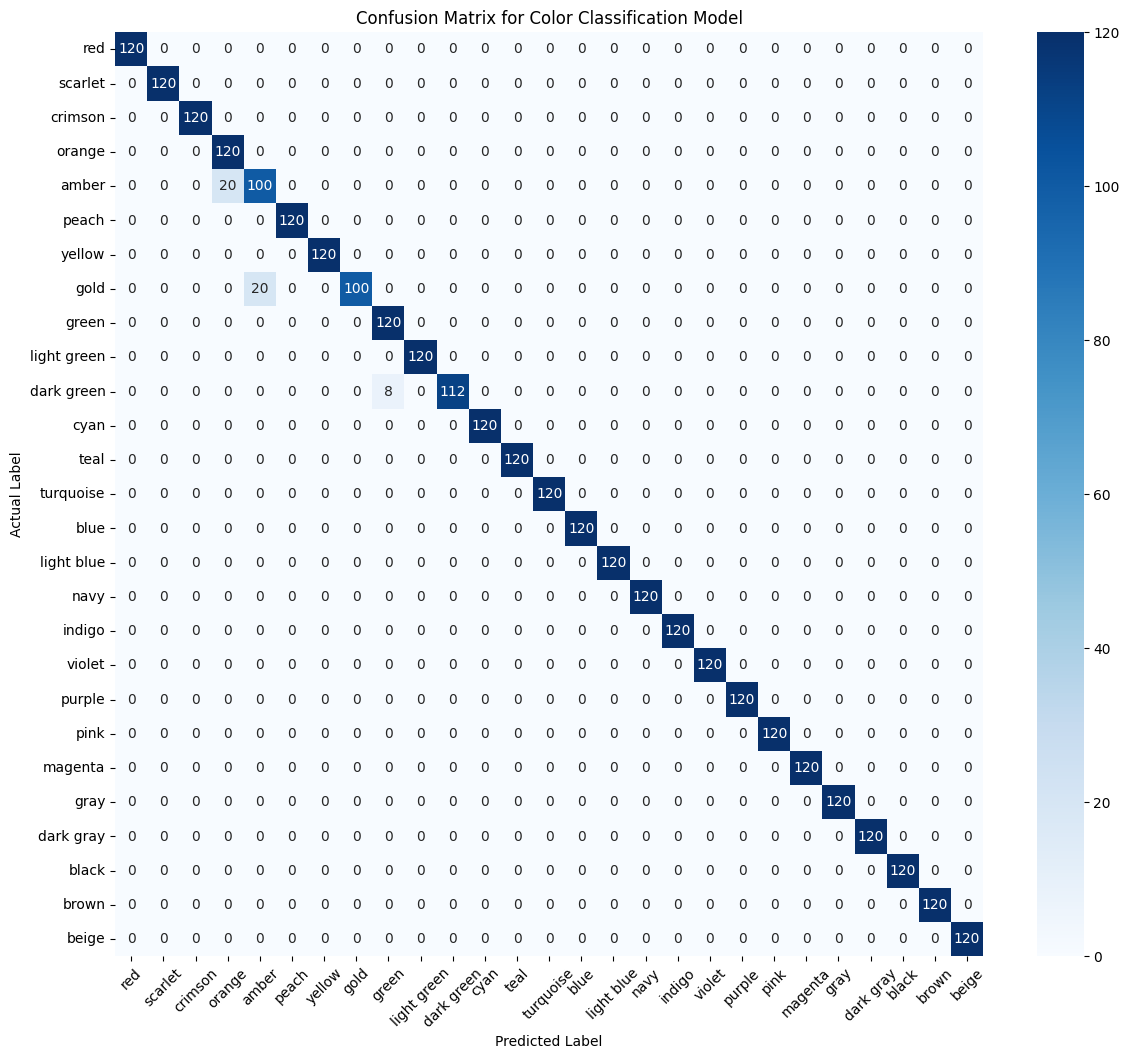

In [ ]:
# ============================================================
# 4. CONFUSION MATRIX HEATMAP
# ============================================================

cm = confusion_matrix(testY, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names
)
plt.title("Confusion Matrix for Color Classification Model")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

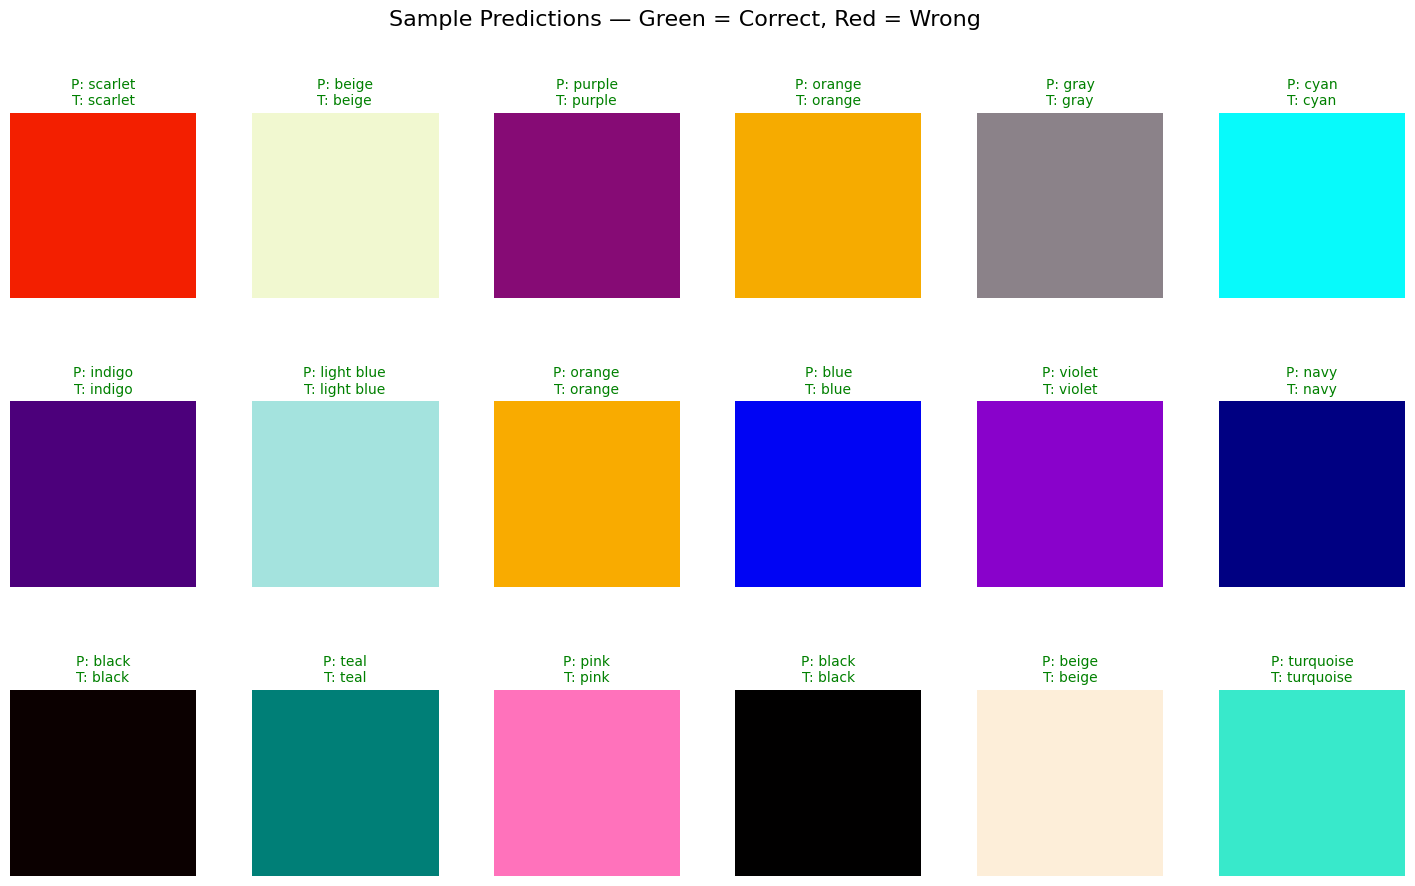

In [ ]:
# ============================================================
# 5. SAMPLE PREDICTIONS VISUALIZATION
# ============================================================

num_samples = 18
cols = 6
rows = num_samples // cols

plt.figure(figsize=(18, 10))
plt.subplots_adjust(hspace=0.5, wspace=0.3)

for i in range(num_samples):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(testX[i])
    true_label = label_names[testY[i]]
    pred_label = label_names[y_pred[i]]

    color = "green" if pred_label == true_label else "red"
    plt.title(f"P: {pred_label}\nT: {true_label}", fontsize=10, color=color)
    plt.axis("off")

plt.suptitle("Sample Predictions — Green = Correct, Red = Wrong", fontsize=16)
plt.show()

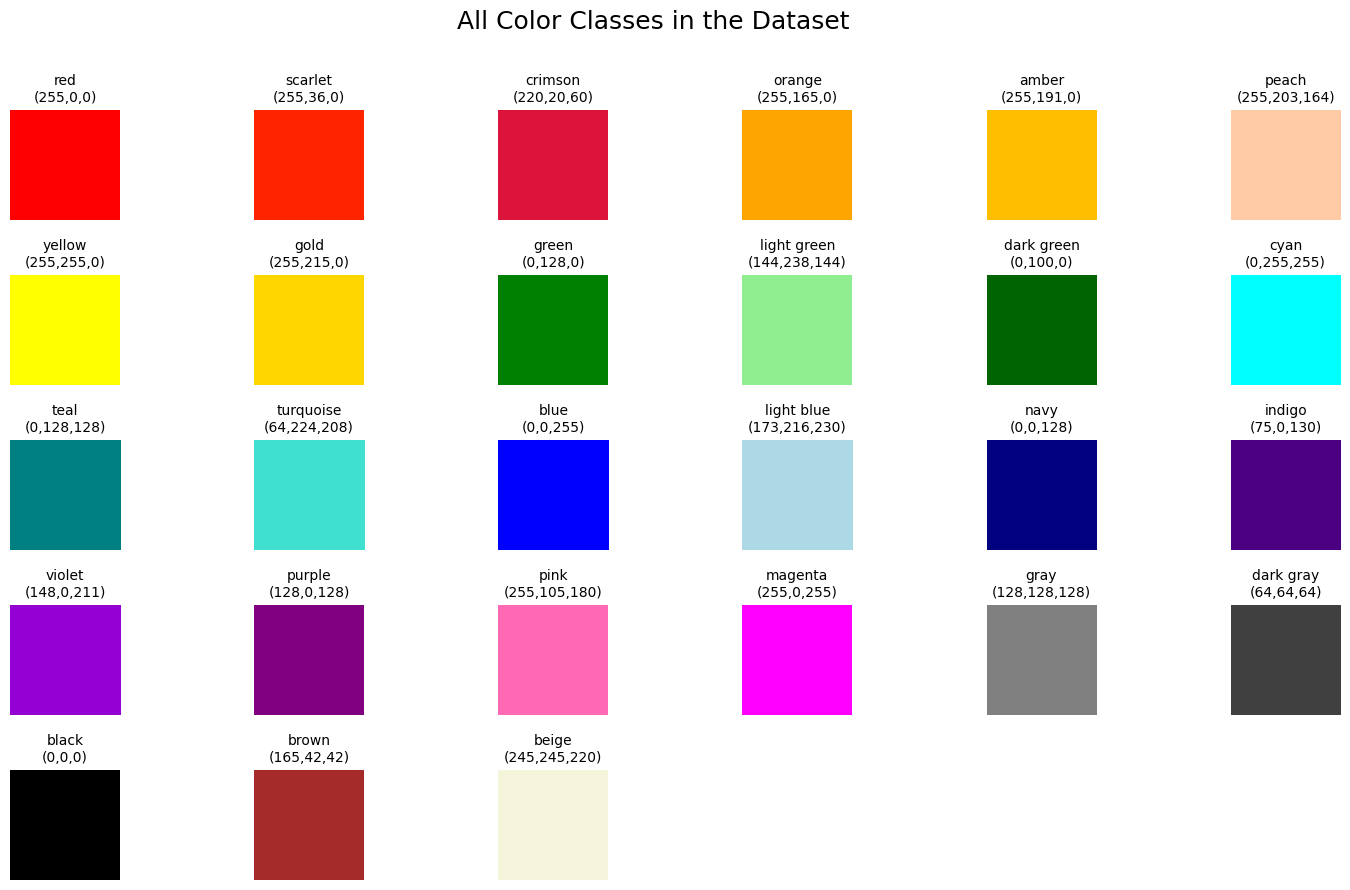

In [ ]:
# ============================================================
# 6. VISUALIZE ALL COLOR CLASSES (Perfect for FYP Report)
# ============================================================

colors = list(psych_colors.items())
num_colors = len(colors)
cols = 6
rows = int(np.ceil(num_colors / cols))

plt.figure(figsize=(18, 10))
plt.subplots_adjust(hspace=0.5, wspace=0.4)

for i, (name, rgb) in enumerate(colors):
    plt.subplot(rows, cols, i + 1)
    patch = np.ones((32, 32, 3), dtype=np.uint8)
    patch[:] = rgb
    r, g, b = rgb
    plt.imshow(patch)
    plt.title(f"{name}\n({r},{g},{b})", fontsize=10)
    plt.axis("off")

plt.suptitle("All Color Classes in the Dataset", fontsize=18)
plt.show()

In [ ]:
# Print final training & validation accuracy
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print("=== FINAL TRAINING RESULTS ===")
print(f"Training Accuracy:    {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"Validation Accuracy:  {val_acc:.4f} ({val_acc*100:.2f}%)")

# Test accuracy (already evaluated earlier)
print(f"Test Accuracy:        {test_acc:.4f} ({test_acc*100:.2f}%)")


=== FINAL TRAINING RESULTS ===
Training Accuracy:    0.9719 (97.19%)
Validation Accuracy:  0.9852 (98.52%)
Test Accuracy:        0.9852 (98.52%)


In [ ]:
# ============================================================
# 8. SAVE MODEL
# ============================================================

save_path = "/content/drive/MyDrive/HiddenTales_ColorModel_Improved.keras"
model_color.save(save_path)
print("Color model saved to:", save_path)

Color model saved to: /content/drive/MyDrive/HiddenTales_ColorModel_Improved.keras


In [ ]:
!find / -name "label_names.json" 2>/dev/null


/content/color_data/label_names.json


In [ ]:
!mkdir -p color_model_export/color_dataset


In [ ]:
!cp "/content/drive/MyDrive/HiddenTales_ColorModel_Improved.keras" color_model_export/


In [ ]:
!cp "/content/color_data/label_names.json" color_model_export/


In [ ]:
!cp "/content/color_data/data.npy" color_model_export/color_dataset/
!cp "/content/color_data/labels.npy" color_model_export/color_dataset/
!cp "/content/color_data/label_names.json" color_model_export/color_dataset/


In [ ]:
!zip -r color_model_export.zip color_model_export


  adding: color_model_export/ (stored 0%)
  adding: color_model_export/label_names.json (deflated 46%)
  adding: color_model_export/HiddenTales_ColorModel_Improved.keras (deflated 9%)
  adding: color_model_export/color_dataset/ (stored 0%)
  adding: color_model_export/color_dataset/labels.npy (deflated 100%)
  adding: color_model_export/color_dataset/label_names.json (deflated 46%)
  adding: color_model_export/color_dataset/data.npy (deflated 100%)


In [ ]:
from google.colab import files
files.download("color_model_export.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Part 2: T5 Model - to generate the NLP Report**

In [ ]:
# ============================================================
# 🔶 PART 2 — NLP REPORT MODEL (FLAN-T5 BASE)
# Synthetic Dataset + T5 Training
# ============================================================

import random
import pandas as pd
import numpy as np


In [ ]:
# ------------------------------------------------------------
# 1. Psychology-Based Emotion → Color Mapping
# (Option B: realistic mappings)
# ------------------------------------------------------------

emotion_color_map = {
    "happy": [
        "yellow", "peach", "pink", "light green", "cyan",
        "turquoise", "light blue", "gold"
    ],
    "sad": [
        "blue", "navy", "indigo", "purple", "violet",
        "gray", "dark gray"
    ],
    "angry": [
        "red", "scarlet", "crimson", "magenta", "orange"
    ],
    "fear": [
        "black", "dark green", "teal", "brown"
    ]
}


In [ ]:
# ------------------------------------------------------------
# 2. Templates for Synthetic Psychologist Reports
# ------------------------------------------------------------

templates = [
    "The drawing uses {colors}, which often reflects {emotion_desc}. This suggests that the child may be experiencing {emotion}.",
    "Colors such as {colors} are commonly linked to {emotion_desc}. The child may be expressing feelings of {emotion}.",
    "By using {colors}, the child conveys {emotion_desc}. This indicates possible emotional states such as {emotion}.",
    "Many children use {colors} when they feel {emotion}. This pattern suggests the child may be processing {emotion_desc}.",
    "The presence of {colors} points toward {emotion_desc}. This may mean the child is feeling {emotion}.",
    "Children often choose {colors} during moments of {emotion}. This drawing indicates {emotion_desc}."
]


In [ ]:
# ------------------------------------------------------------
# 3. Emotion Descriptions (for natural language variety)
# ------------------------------------------------------------

emotion_descriptions = {
    "happy": ["joy", "excitement", "comfort", "positive energy"],
    "sad": ["sadness", "loneliness", "low mood"],
    "angry": ["frustration", "anger", "strong emotional stress"],
    "fear": ["fear", "anxiety", "worry"]
}

In [ ]:
# ------------------------------------------------------------
# 4. Synthetic Dataset Generator
# ------------------------------------------------------------

def generate_example():
    emotion = random.choice(list(emotion_color_map.keys()))
    possible_colors = emotion_color_map[emotion]

    # choose 1–3 colors per report
    num_colors = random.randint(1, 3)
    chosen_colors = random.sample(possible_colors, num_colors)

    colors_str = ", ".join(chosen_colors)
    primary_color = chosen_colors[0]

    emotion_desc = random.choice(emotion_descriptions[emotion])
    template = random.choice(templates)

    report = template.format(
        colors=colors_str,
        emotion_desc=emotion_desc,
        emotion=emotion
    )

    return {
        "emotion": emotion,
        "colors": colors_str,
        "primary_color": primary_color,
        "report": report
    }

In [ ]:
# ------------------------------------------------------------
# 5. Generate Large Synthetic Dataset (~3000 rows)
# ------------------------------------------------------------

dataset = [generate_example() for _ in range(3000)]
df = pd.DataFrame(dataset)

df.to_csv("psychologist_dataset.csv", index=False)
df.head()

,emotion,colors,primary_color,report
0,fear,"teal, brown, dark green",teal,"Many children use teal, brown, dark green when..."
1,angry,"red, scarlet",red,"Colors such as red, scarlet are commonly linke..."
2,happy,yellow,yellow,Colors such as yellow are commonly linked to c...
3,fear,"teal, dark green, black",teal,"Colors such as teal, dark green, black are com..."
4,sad,violet,violet,The presence of violet points toward low mood....


In [ ]:
# ============================================================
# 6. Load FLAN-T5 BASE + Tokenizer
# ============================================================

!pip install transformers sentencepiece accelerate -q

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from datasets import Dataset
from sklearn.model_selection import train_test_split

tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-base")
model = AutoModelForSeq2SeqLM.from_pretrained("google/flan-t5-base")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [ ]:
# ------------------------------------------------------------
# 7. Prepare Dataset for Training
# ------------------------------------------------------------

df = pd.read_csv("psychologist_dataset.csv")

train_df, val_df = train_test_split(df, test_size=0.1, random_state=42)

train_ds = Dataset.from_pandas(train_df)
val_ds = Dataset.from_pandas(val_df)

# Input format for T5
def preprocess(examples):
    inputs = []
    for e, c, p in zip(examples["emotion"], examples["colors"], examples["primary_color"]):
        text = f"emotion: {e} | colors: {c} | primary: {p}"
        inputs.append(text)

    model_inputs = tokenizer(
        inputs,
        max_length=128,
        truncation=True,
        padding='max_length' # Added padding here
    )

    labels = tokenizer(
        examples["report"],
        max_length=128,
        truncation=True,
        padding='max_length' # Added padding here
    )

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

train_ds = train_ds.map(preprocess, batched=True)
val_ds = val_ds.map(preprocess, batched=True)

Map:   0%|          | 0/2700 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

In [ ]:
from transformers import TrainingArguments, Trainer, DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model
)

training_args = TrainingArguments(
    output_dir="/content/t5_report_model",
    do_eval=True,
    logging_steps=50,
    learning_rate=2e-4,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=8,
    weight_decay=0.01,
    warmup_ratio=0.1,
    save_strategy="epoch",
    push_to_hub=False
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator
)

trainer.train()


 ··········


Step,Training Loss
50,32.424200
100,11.821900
150,2.172600
200,0.255200
250,0.059000
300,0.042400
350,0.038500
400,0.034200
450,0.033300
500,0.031400


TrainOutput(global_step=5400, training_loss=0.45750141821525714, metrics={'train_runtime': 2023.4117, 'train_samples_per_second': 10.675, 'train_steps_per_second': 2.669, 'total_flos': 3697689703219200.0, 'train_loss': 0.45750141821525714, 'epoch': 8.0})

In [ ]:
!pip install evaluate -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.9 MB/s eta 0:00:00


In [ ]:
!pip install evaluate rouge_score -q
from evaluate import load
import numpy as np

metric = load("rouge")

def compute_rouge(preds, labels):
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    return metric.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)

generated_predictions = []
true_labels = []

for batch in val_ds:
    input_text = f"emotion: {batch['emotion']} | colors: {batch['colors']} | primary: {batch['primary_color']}"

    # 🔥 FIX: put inputs on the SAME DEVICE as the model
    inputs = tokenizer(input_text, return_tensors="pt").to(model.device)

    output = model.generate(**inputs, max_length=128)

    generated_predictions.append(output[0])
    true_labels.append(batch["report"])

# Decode both
decoded_preds = tokenizer.batch_decode(generated_predictions, skip_special_tokens=True)
decoded_labels = true_labels

# Compute ROUGE
rouge_results = metric.compute(predictions=decoded_preds, references=decoded_labels)

print("=== FINAL ROUGE METRICS ===")
print("ROUGE-1:", rouge_results["rouge1"])
print("ROUGE-2:", rouge_results["rouge2"])
print("ROUGE-L:", rouge_results["rougeL"])


  Preparing metadata (setup.py) ... done


=== FINAL ROUGE METRICS ===
ROUGE-1: 0.505255583948043
ROUGE-2: 0.26975318210850524
ROUGE-L: 0.43135560976873955


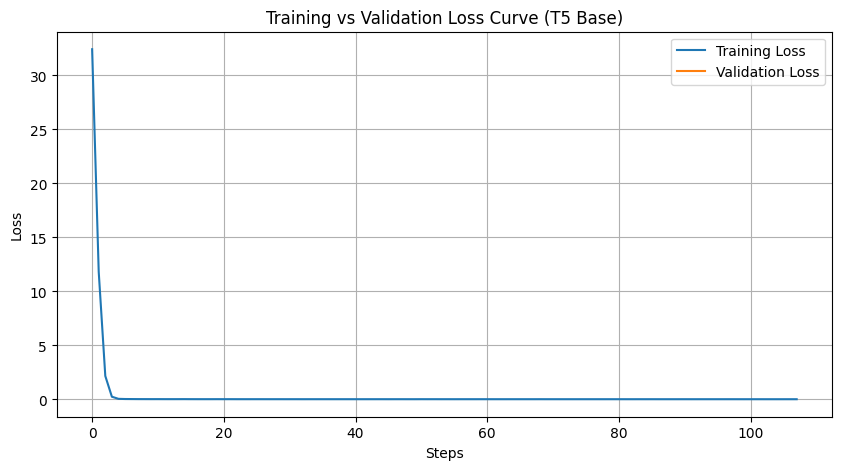

In [ ]:
# =============================================================
# 📈 TRAINING LOSS CURVE
# =============================================================
import matplotlib.pyplot as plt

logs = trainer.state.log_history

train_loss = [entry["loss"] for entry in logs if "loss" in entry]
eval_loss = [entry["eval_loss"] for entry in logs if "eval_loss" in entry]

plt.figure(figsize=(10, 5))
plt.plot(train_loss, label="Training Loss")
plt.plot(eval_loss, label="Validation Loss")
plt.title("Training vs Validation Loss Curve (T5 Base)")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import pandas as pd

rouge_table = pd.DataFrame({
    "Metric": ["ROUGE-1", "ROUGE-2", "ROUGE-L"],
    "Score": [
        rouge_results["rouge1"],
        rouge_results["rouge2"],
        rouge_results["rougeL"],
    ]
})

rouge_table


,Metric,Score
0,ROUGE-1,0.505256
1,ROUGE-2,0.269753
2,ROUGE-L,0.431356


In [ ]:
# =============================================================
# 🧪 SAMPLE PREDICTIONS FOR REPORT
# =============================================================
for i in range(10):
    print("="*80)
    row = val_df.iloc[i]

    input_text = f"emotion: {row['emotion']} | colors: {row['colors']} | primary: {row['primary_color']}"
    inputs = tokenizer(input_text, return_tensors="pt").to(model.device)
    output = model.generate(**inputs, max_length=128)
    pred = tokenizer.decode(output[0], skip_special_tokens=True)

    print(f"🔹 INPUT  : {input_text}")
    print(f"🔹 TARGET : {row['report']}")
    print(f"🔹 PREDICTED:\n{pred}\n")


🔹 INPUT  : emotion: angry | colors: red, crimson | primary: red
🔹 TARGET : The drawing uses red, crimson, which often reflects anger. This suggests that the child may be experiencing angry.
🔹 PREDICTED:
The drawing uses red, crimson, which often reflects strong emotional stress. This suggests that the child may be experiencing angry.

🔹 INPUT  : emotion: sad | colors: blue, dark gray | primary: blue
🔹 TARGET : The drawing uses blue, dark gray, which often reflects loneliness. This suggests that the child may be experiencing sad.
🔹 PREDICTED:
The presence of blue, dark gray points toward sadness. This may mean the child is feeling sad.

🔹 INPUT  : emotion: happy | colors: light green, yellow, gold | primary: light green
🔹 TARGET : The drawing uses light green, yellow, gold, which often reflects joy. This suggests that the child may be experiencing happy.
🔹 PREDICTED:
The presence of light green, yellow, gold points toward excitement. This may mean the child is feeling happy.

🔹 INPUT  :

In [ ]:
# =============================================================
# 📄 SIDE-BY-SIDE TARGET VS PREDICTION TABLE
# =============================================================
records = []

for i in range(20):
    row = val_df.iloc[i]

    input_text = f"emotion: {row['emotion']} | colors: {row['colors']} | primary: {row['primary_color']}"
    inputs = tokenizer(input_text, return_tensors="pt").to(model.device)
    output = model.generate(**inputs, max_length=128)
    predicted = tokenizer.decode(output[0], skip_special_tokens=True)

    records.append([
        row["emotion"],
        row["colors"],
        row["primary_color"],
        row["report"],
        predicted
    ])

import pandas as pd
comparison_df = pd.DataFrame(records, columns=[
    "Emotion", "Colors Used", "Primary Color",
    "Actual Report", "Generated Report"
])

comparison_df


,Emotion,Colors Used,Primary Color,Actual Report,Generated Report
0,angry,"red, crimson",red,"The drawing uses red, crimson, which often ref...","By using red, crimson, the child conveys stron..."
1,sad,"blue, dark gray",blue,"The drawing uses blue, dark gray, which often ...","Many children use blue, dark gray when they fe..."
2,happy,"light green, yellow, gold",light green,"The drawing uses light green, yellow, gold, wh...","The presence of light green, yellow, gold poin..."
3,angry,"magenta, crimson, red",magenta,"The drawing uses magenta, crimson, red, which ...","Children often choose magenta, crimson, red du..."
4,happy,cyan,cyan,"The drawing uses cyan, which often reflects po...",The presence of cyan points toward excitement....
5,sad,"navy, purple",navy,"The presence of navy, purple points toward lon...","Many children use navy, purple when they feel ..."
6,angry,"orange, magenta, crimson",orange,"Many children use orange, magenta, crimson whe...","The drawing uses orange, magenta, crimson, whi..."
7,sad,dark gray,dark gray,The presence of dark gray points toward loneli...,"The drawing uses dark gray, which often reflec..."
8,sad,gray,gray,Colors such as gray are commonly linked to sad...,"By using gray, the child conveys low mood. Thi..."
9,fear,"black, dark green, brown",black,"Colors such as black, dark green, brown are co...","The drawing uses black, dark green, brown, whi..."


In [ ]:
print("===== T5 MODEL PERFORMANCE SUMMARY =====")

# Training loss from training logs
print(f"Training Loss      : {train_loss[-1]:.4f}")

# Validation loss directly from evaluation call
eval_output = trainer.evaluate()
print(f"Final Val Loss     : {eval_output['eval_loss']:.4f}")

# ROUGE scores
print(f"ROUGE-1 (Precision): {rouge_results['rouge1']}")
print(f"ROUGE-2 (Precision): {rouge_results['rouge2']}")
print(f"ROUGE-L (Precision): {rouge_results['rougeL']}")


===== T5 MODEL PERFORMANCE SUMMARY =====
Training Loss      : 0.0238


Final Val Loss     : 0.0236
ROUGE-1 (Precision): 0.505255583948043
ROUGE-2 (Precision): 0.26975318210850524
ROUGE-L (Precision): 0.43135560976873955


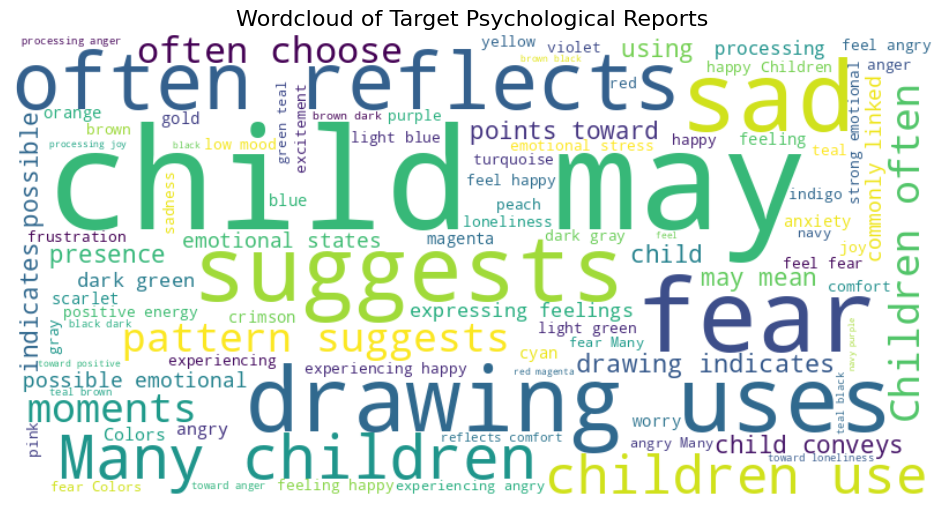

In [ ]:
!pip install wordcloud -q
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_text = " ".join(val_df["report"])

wc = WordCloud(width=800, height=400, background_color="white").generate(all_text)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Wordcloud of Target Psychological Reports", fontsize=16)
plt.show()


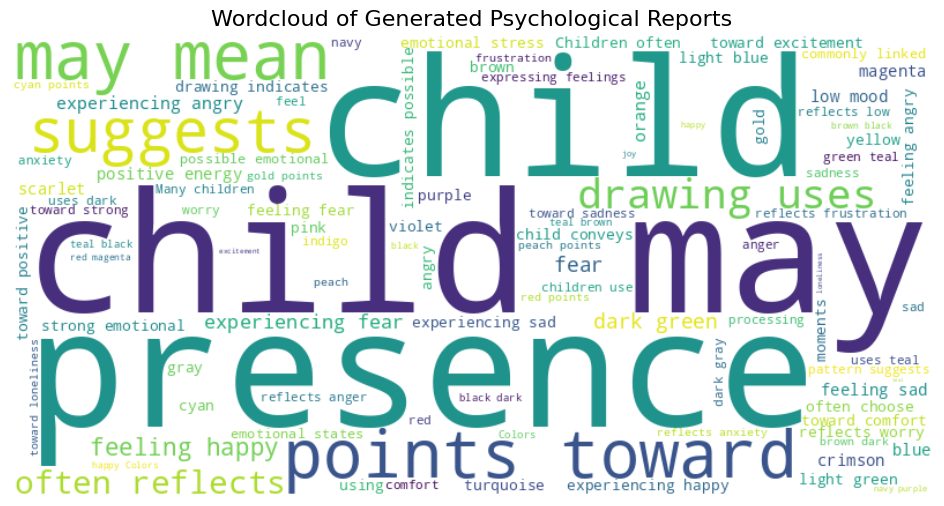

In [ ]:
generated_text = " ".join(decoded_preds)

wc2 = WordCloud(width=800, height=400, background_color="white").generate(generated_text)

plt.figure(figsize=(12, 6))
plt.imshow(wc2, interpolation="bilinear")
plt.axis("off")
plt.title("Wordcloud of Generated Psychological Reports", fontsize=16)
plt.show()


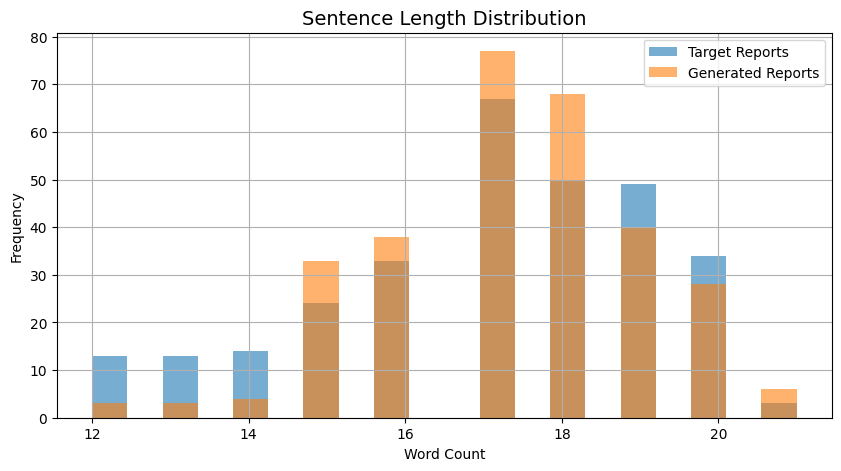

In [ ]:
target_lengths = [len(t.split()) for t in val_df["report"]]
predicted_lengths = [len(t.split()) for t in decoded_preds]

plt.figure(figsize=(10,5))
plt.hist(target_lengths, bins=20, alpha=0.6, label='Target Reports')
plt.hist(predicted_lengths, bins=20, alpha=0.6, label='Generated Reports')
plt.title("Sentence Length Distribution", fontsize=14)
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
!find /content -maxdepth 5 -type d -name "*T5*" 2>/dev/null
!find /content/drive/MyDrive -maxdepth 5 -type d -name "*T5*" 2>/dev/null


/content/drive/MyDrive/T5_AntiOverfit
/content/drive/MyDrive/HiddenTales_T5_Final
/content/drive/MyDrive/T5_Model_Backup
/content/drive/.Encrypted/MyDrive/T5_AntiOverfit
/content/drive/.Encrypted/MyDrive/HiddenTales_T5_Final
/content/drive/.Encrypted/MyDrive/T5_Model_Backup
/content/drive/MyDrive/T5_AntiOverfit
/content/drive/MyDrive/HiddenTales_T5_Final
/content/drive/MyDrive/T5_Model_Backup
/content/drive/MyDrive/T5_Model_Backup/content/drive/MyDrive/HiddenTales_T5_Final


In [ ]:
!mkdir -p nlp_model_export


In [ ]:
!cp -r "/content/drive/MyDrive/HiddenTales_T5_Final" nlp_model_export/


In [ ]:
!cp "/content/psychologist_dataset.csv" nlp_model_export/


In [ ]:
!zip -r nlp_model_export.zip nlp_model_export


  adding: nlp_model_export/ (stored 0%)
  adding: nlp_model_export/psychologist_dataset.csv (deflated 93%)
  adding: nlp_model_export/HiddenTales_T5_Final/ (stored 0%)
  adding: nlp_model_export/HiddenTales_T5_Final/tokenizer_config.json (deflated 95%)
  adding: nlp_model_export/HiddenTales_T5_Final/config.json (deflated 63%)
  adding: nlp_model_export/HiddenTales_T5_Final/model.safetensors (deflated 7%)
  adding: nlp_model_export/HiddenTales_T5_Final/tokenizer.json (deflated 74%)
  adding: nlp_model_export/HiddenTales_T5_Final/spiece.model (deflated 48%)
  adding: nlp_model_export/HiddenTales_T5_Final/special_tokens_map.json (deflated 85%)
  adding: nlp_model_export/HiddenTales_T5_Final/generation_config.json (deflated 29%)


In [ ]:
from google.colab import files
files.download("nlp_model_export.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>